##### 1. Load Libraries

In [1]:
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import os
import json
try:
    import optuna
except ImportError:
    optuna = None

c:\Users\jaira\OneDrive\Documents\MEGA\University\Biomed Eng Research\Raman Analysis Project\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### 2. Load and Add Target Columns
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def read_all_csvs_to_df(folder_path):
    dataframes = []

    file_list = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))

    for i, file_name in enumerate(file_list):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        dataframes.append(df.assign(target=target_value))

    combined_df = pd.concat(dataframes, ignore_index=True)

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_path = os.path.join("..", "data", "mixed_ratio")
df = read_all_csvs_to_df(folder_path)

# for testing
#print(df.head())

C:\Users\jaira\AppData\Local\Temp\ipykernel_20140\3008409842.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframes.append(df.assign(target=target_value))
C:\Users\jaira\AppData\Local\Temp\ipykernel_20140\3008409842.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])


##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
def label_data(dataframe):
    feature_cols = [
        col for col in dataframe.columns
        if col not in ["target", "target_encoded"]
    ]

    feature_values = dataframe.loc[0, feature_cols]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df


#for testing
clean_df = label_data(df)
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Training the Model
In this cell, a function to train the model is being defined. Random state can be changed to a random number if need be, 42 was just an arbitrary value chosen for testing reproducibility. Actual model training will begin later when this function is called.

In [4]:
def train_xgboost_model(
    df: pd.DataFrame,
    target_col: str = "target_encoded",
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_state: int = 42,
    n_trials: int = 50,
    use_optuna: bool = False,
    fixed_params: dict | None = None,
    return_study: bool = False
):
    """
    Splits the dataframe into train/test sets and returns an XGBoost classifier.
    You can either tune hyperparameters with Optuna or pass fixed parameters.

    Parameters:
        df (pd.DataFrame): Input dataframe containing features and target.
        target_col (str): Name of the encoded target column.
        test_size (float): Fraction of data to use for final testing.
        val_size (float): Fraction of training data to use for validation during tuning.
        random_state (int): Seed for reproducibility.
        n_trials (int): Number of Optuna trials.
        use_optuna (bool): Whether to run Optuna hyperparameter tuning.
        fixed_params (dict | None): Precomputed XGBoost parameters to use when not tuning.
        return_study (bool): Whether to also return the Optuna study object.

    Returns:
        model: Final XGBClassifier
        X_train, X_test, y_train, y_test: Final split datasets
        study: Optuna study object, only when return_study=True
    """
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Final holdout test set
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    study = None

    if use_optuna:
        if optuna is None:
            raise ImportError("Optuna is not installed. Set use_optuna=False or install optuna.")

        # Inner split for Optuna tuning / validation
        X_train_inner, X_val, y_train_inner, y_val = train_test_split(
            X_train,
            y_train,
            test_size=val_size,
            random_state=random_state,
            stratify=y_train
        )

        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
                "max_depth": trial.suggest_int("max_depth", 2, 6),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                "min_child_weight": trial.suggest_float("min_child_weight", 1, 15),
                "subsample": trial.suggest_float("subsample", 0.5, 0.9),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),
                "gamma": trial.suggest_float("gamma", 0.0, 5.0),
                "random_state": random_state,
                # "n_jobs": -1,         # CPU only — replaced by device="cuda"
                # "tree_method": "hist", # CPU hist — replaced by device="cuda"
                "device": "cuda",        # GPU acceleration (XGBoost 2.0+)
                "eval_metric": "mlogloss",
            }

            model = XGBClassifier(**params)
            model.fit(X_train_inner, y_train_inner, eval_set=[(X_val, y_val)], verbose=False)

            y_val_pred = model.predict(X_val)
            return accuracy_score(y_val, y_val_pred)

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials)

        best_params = study.best_params
        print("Best trial score:", study.best_value)
        print("Best params:", best_params)
    else:
        best_params = fixed_params or {}
        if best_params:
            print("Using fixed params:", best_params)

    # Final tuned model
    final_model = XGBClassifier(
        **best_params,
        random_state=random_state,
        # n_jobs=-1,          # CPU only — replaced by device="cuda"
        # tree_method="hist", # CPU hist — replaced by device="cuda"
        device="cuda",        # GPU acceleration (XGBoost 2.0+)
        eval_metric="mlogloss",
    )

    final_model.fit(X_train, y_train)

    if return_study:
        return final_model, X_train, X_test, y_train, y_test, study

    return final_model, X_train, X_test, y_train, y_test

##### 5. Model Evaluation
Model evaluation functions are being defined here. The classification report export can be disabled by passing an argument to the function class. 

In [5]:
def get_unique_export_path(file_name):
    """Return a non-overwriting file path by appending a counter if needed."""
    base_name, ext = os.path.splitext(file_name)
    candidate = file_name
    counter = 1

    while os.path.exists(candidate):
        candidate = f"{base_name}_{counter}{ext}"
        counter += 1

    return candidate

def eval_model(model, X_test, y_test, save_path="confusion_matrix.png", report_filename="classification_report.csv"):
    """
    Evaluates a trained XGBoost model on the test set.

    Parameters:
        model: Trained classifier
        X_test (pd.DataFrame): Test features
        y_test (pd.Series or np.ndarray): True test labels
        save_path (str): File path for the saved confusion matrix image

    Returns:
        results (dict): Dictionary of evaluation results
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()
    report_export_path = get_unique_export_path(report_filename)
    report_df.to_csv(report_export_path, index=True)

    labels = sorted(set(y_test) | set(y_pred))

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("XGBoost Confusion Matrix")
    fig.tight_layout()

    # Uncomment if you want to save the figure
    # fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print(f"Confusion matrix save path: {save_path}")
    print(f"Classification report CSV saved to: {report_export_path}")
    print("\nClassification Report:")
    print(report)

    results = {
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm,
        "classification_report": report,
        "classification_report_csv_path": report_export_path,
        "confusion_matrix_path": save_path
    }

    return results

##### 6. Creating Noisy Spectra

In [6]:
def add_white_noise_to_features(
    X: pd.DataFrame,
    noise_level: float = 0.05,
    random_state: int = 42,
    relative: bool = True
) -> pd.DataFrame:
    """
    Create a noisy copy of spectral feature rows by adding Gaussian white noise.

    Parameters:
        X (pd.DataFrame): Feature dataframe only (no target column).
        noise_level (float): Noise strength.
            If relative=True, this is multiplied by each row's std.
            If relative=False, this is used as the std of the noise directly.
        random_state (int): Seed for reproducibility.
        relative (bool): If True, scale noise by each row's spectral std.
                         If False, use fixed std for all features.

    Returns:
        X_noisy (pd.DataFrame): Noisy copy of X with same shape/index/columns.
    """
    rng = np.random.default_rng(random_state)
    X_values = X.to_numpy(dtype=float)

    if relative:
        row_std = X_values.std(axis=1, keepdims=True)
        # avoid zero std rows causing zero-noise outputs
        row_std = np.where(row_std == 0, 1e-8, row_std)
        noise = rng.normal(loc=0.0, scale=noise_level * row_std, size=X_values.shape)
    else:
        noise = rng.normal(loc=0.0, scale=noise_level, size=X_values.shape)

    X_noisy = X_values + noise

    return pd.DataFrame(X_noisy, columns=X.columns, index=X.index)

##### 7. Let's run it!
This is where all the functions written above come together. If you would like to save your model and use it later on for classification, set the save_model argument to True. 

Using fixed params: {'n_estimators': 1170, 'max_depth': 4, 'learning_rate': 0.06036450947667917, 'min_child_weight': 10.934131465380219, 'subsample': 0.8984148947112249, 'colsample_bytree': 0.6455710149287527, 'reg_alpha': 0.00012956833208514377, 'reg_lambda': 0.004832706748706296, 'gamma': 0.06535901811391526}


c:\Users\jaira\OneDrive\Documents\MEGA\University\Biomed Eng Research\Raman Analysis Project\.venv312\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:25:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Train Accuracy: 1.0
Test Accuracy: 0.9727
Accuracy Gap: 0.0273

Cross-Validation Accuracy Scores: [0.9287 0.9855 0.9192 0.9655 0.7955]
CV Mean Accuracy: 0.9189
CV Std Dev: 0.0662


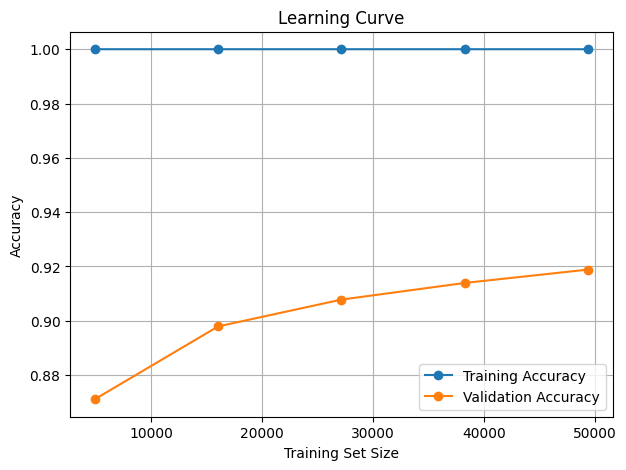


=== Evaluation on Clean Test Set ===


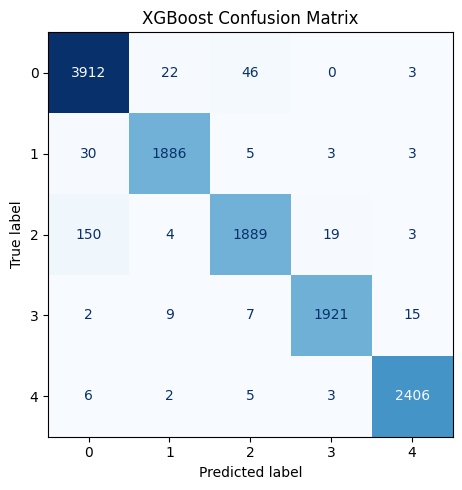

Accuracy: 0.9727
Weighted F1: 0.9726
Confusion matrix save path: confusion_matrix.png
Classification report CSV saved to: classification_report_clean_2.csv

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      3983
           1       0.98      0.98      0.98      1927
           2       0.97      0.91      0.94      2065
           3       0.99      0.98      0.99      1954
           4       0.99      0.99      0.99      2422

    accuracy                           0.97     12351
   macro avg       0.98      0.97      0.97     12351
weighted avg       0.97      0.97      0.97     12351


=== Evaluation on Noisy Test Set ===


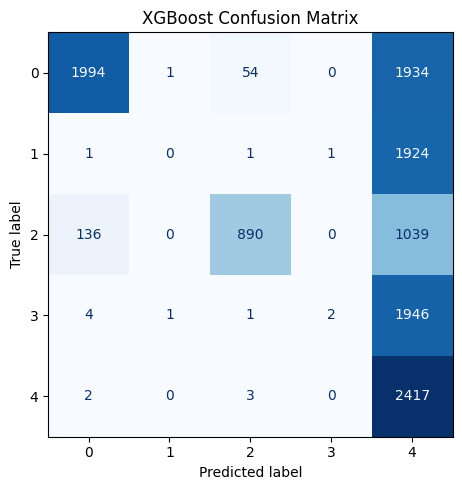

Accuracy: 0.4294
Weighted F1: 0.3904
Confusion matrix save path: confusion_matrix.png
Classification report CSV saved to: classification_report_noisy_2.csv

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.50      0.65      3983
           1       0.00      0.00      0.00      1927
           2       0.94      0.43      0.59      2065
           3       0.67      0.00      0.00      1954
           4       0.26      1.00      0.41      2422

    accuracy                           0.43     12351
   macro avg       0.56      0.39      0.33     12351
weighted avg       0.61      0.43      0.39     12351



In [7]:
def main():
    """
    Main workflow for training and evaluating the XGBoost model.
    Assumes the dataframe 'clean_df' already exists in the notebook.
    """
    best_params = {
        "n_estimators": 1170,
        "max_depth": 4,
        "learning_rate": 0.06036450947667917,
        "min_child_weight": 10.934131465380219,
        "subsample": 0.8984148947112249,
        "colsample_bytree": 0.6455710149287527,
        "reg_alpha": 0.00012956833208514377,
        "reg_lambda": 0.004832706748706296,
        "gamma": 0.06535901811391526
    }

    model, X_train, X_test, y_train, y_test = train_xgboost_model(
        df=clean_df,
        target_col="target_encoded",
        test_size=0.2,
        random_state=42,
        use_optuna=False,
        fixed_params=best_params
    )


    # Various methods to check for over fitting
    # ---------------------------------------------------
    # Compare training vs test performance
    # ---------------------------------------------------
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print("Train Accuracy:", round(train_acc, 4))
    print("Test Accuracy:", round(test_acc, 4))
    print("Accuracy Gap:", round(train_acc - test_acc, 4))

    # ---------------------------------------------------
    # Cross-validation performance
    # ---------------------------------------------------
    X_full = clean_df.drop(columns=["target_encoded"])
    y_full = clean_df["target_encoded"]

    cv_scores = cross_val_score(model, X_full, y_full, cv=5, scoring="accuracy")

    print("\nCross-Validation Accuracy Scores:", np.round(cv_scores, 4))
    print("CV Mean Accuracy:", round(cv_scores.mean(), 4))
    print("CV Std Dev:", round(cv_scores.std(), 4))

    # ---------------------------------------------------
    # Learning curve
    # ---------------------------------------------------
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_full,
        y_full,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
    plt.plot(train_sizes, val_mean, marker='o', label="Validation Accuracy")
    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------------------------------------------
    # Clean test evaluation
    # ---------------------------------------------------
    print("\n=== Evaluation on Clean Test Set ===")
    clean_results = eval_model(model, X_test, y_test, report_filename="classification_report_clean.csv")

    # ---------------------------------------------------
    # Noisy test evaluation
    # ---------------------------------------------------
    X_test_noisy = add_white_noise_to_features(
        X_test,
        noise_level=0.05,   # adjust this as needed
        random_state=42,
        relative=True
    )

    print("\n=== Evaluation on Noisy Test Set ===")
    noisy_results = eval_model(model, X_test_noisy, y_test, report_filename="classification_report_noisy.csv")

    return model, clean_results, noisy_results

model, clean_results, noisy_results = main()